# EmpiricalDistribution

A distribution built from observed data using a density estimator (Gaussian KDE by default).  
The PDF is provided analytically via the estimator; CDF and PPF are derived automatically by the characteristic graph.

**Two key features:**
- `with_method(m)` — returns an independent copy with a different method (the original is unchanged)
- `set_method(m)` — replaces the method in-place on the same object (cache and sampler are reset automatically)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.distributions.empirical import EmpiricalDistribution, ScipyGaussianKde

## 1. Data

A mixture of two Gaussians — a bimodal sample where KDE methods behave differently.

In [2]:
rng = np.random.default_rng(42)
sample = np.concatenate(
    [
        rng.normal(loc=-2.5, scale=0.8, size=400),
        rng.normal(loc=3.0, scale=1.2, size=600),
    ]
)

x = np.linspace(sample.min() - 1.0, sample.max() + 1.0, 500)
quant = np.linspace(0.01, 0.99, 300)

print(f"sample size: {len(sample)}, range: [{sample.min():.2f}, {sample.max():.2f}]")

sample size: 1000, range: [-4.55, 6.81]


## 2. Basic characteristics

PDF, CDF (∫ PDF dx via the characteristic graph), PPF (PCHIP inversion of the CDF), new samples.

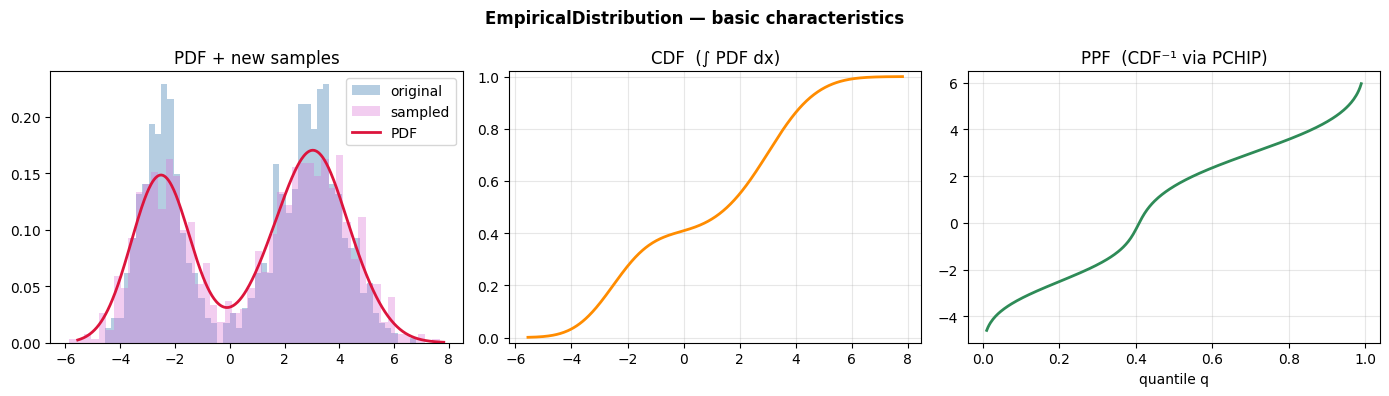

In [3]:
distr = EmpiricalDistribution(sample, method=ScipyGaussianKde(bandwidth="silverman"))

pdf_vals = distr.calculate_characteristic("pdf", x)
cdf_vals = distr.calculate_characteristic("cdf", x)
ppf_vals = distr.calculate_characteristic("ppf", quant)
new_samples = distr.sample(1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("EmpiricalDistribution — basic characteristics", fontweight="bold")

axes[0].hist(sample, bins=50, density=True, alpha=0.4, color="steelblue", label="original")
axes[0].hist(new_samples, bins=50, density=True, alpha=0.35, color="orchid", label="sampled")
axes[0].plot(x, pdf_vals, color="crimson", lw=2, label="PDF")
axes[0].set_title("PDF + new samples")
axes[0].legend()

axes[1].plot(x, cdf_vals, color="darkorange", lw=2)
axes[1].set_title("CDF  (∫ PDF dx)")
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(alpha=0.3)

axes[2].plot(quant, ppf_vals, color="seagreen", lw=2)
axes[2].set_title("PPF  (CDF⁻¹ via PCHIP)")
axes[2].set_xlabel("quantile q")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. `with_method` — side-by-side method comparison

`with_method(m)` returns a **new** object with a different method fitted on the same sample.  
The original `distr` is unchanged. Each object's strategies are independent.

In [4]:
methods = {
    "silverman": distr,
    "scott": distr.with_method(ScipyGaussianKde(bandwidth="scott")),
    "bw=0.15": distr.with_method(ScipyGaussianKde(bandwidth=0.15)),
    "bw=0.70": distr.with_method(ScipyGaussianKde(bandwidth=0.70)),
}

assert methods["silverman"] is distr
assert methods["scott"] is not distr

for _name, d in methods.items():
    assert d.data is sample
print("sample shared across all clones: OK")

strats = [d.computation_strategy for d in methods.values()]
assert len({id(s) for s in strats}) == len(strats)
print("computation strategies are independent: OK")

sample shared across all clones: OK
computation strategies are independent: OK


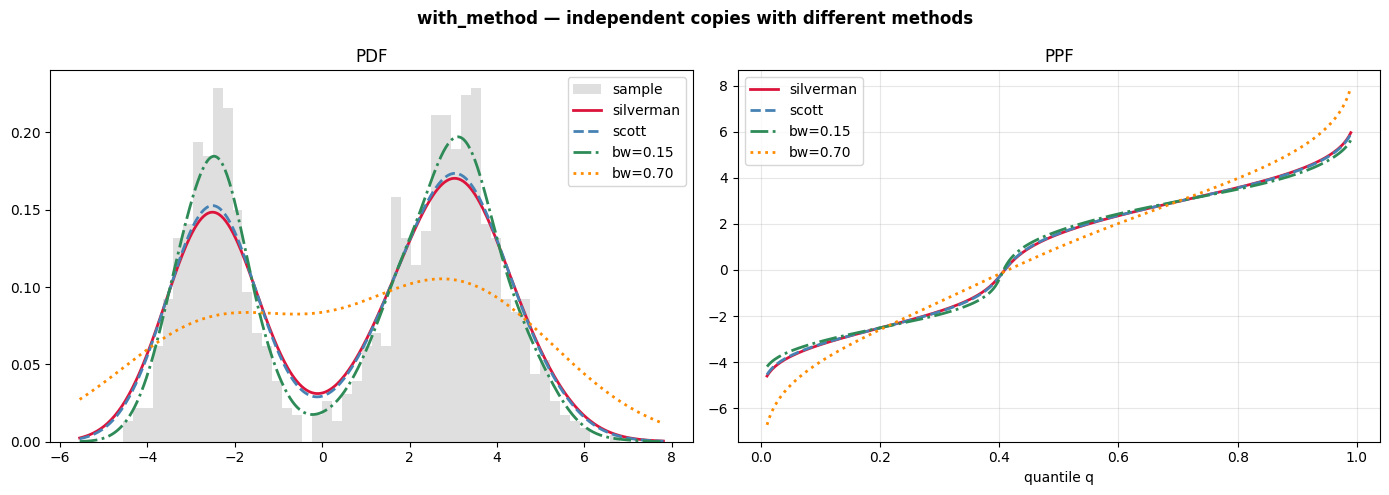

In [5]:
colors = ["crimson", "steelblue", "seagreen", "darkorange"]
styles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("with_method — independent copies with different methods", fontweight="bold")

axes[0].hist(sample, bins=50, density=True, alpha=0.25, color="gray", label="sample")
for (name, d), c, ls in zip(methods.items(), colors, styles, strict=False):
    axes[0].plot(x, d.calculate_characteristic("pdf", x), color=c, ls=ls, lw=2, label=name)
axes[0].set_title("PDF")
axes[0].legend()

for (name, d), c, ls in zip(methods.items(), colors, styles, strict=False):
    axes[1].plot(quant, d.calculate_characteristic("ppf", quant), color=c, ls=ls, lw=2, label=name)
axes[1].set_title("PPF")
axes[1].set_xlabel("quantile q")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. `set_method` — in-place method replacement

`set_method(m)` replaces the method **on the same object**:
- the fitted estimator is rebuilt as `m.fit(sample)`, so `distr.method` reports the new method
- `EmpiricalComputationStrategy` notices the estimator changed and drops its cached fits on the next query
- the UNURAN sampler is reset explicitly, because its C-side init captured the old PDF

The sample itself is reused, not copied.

In [6]:
distr_mut = EmpiricalDistribution(sample, method=ScipyGaussianKde(bandwidth=0.7))

id_distr_before = id(distr_mut)
method_before = distr_mut.method

pdf_before = distr_mut.calculate_characteristic("pdf", x)
cdf_before = distr_mut.calculate_characteristic("cdf", x)
ppf_before = distr_mut.calculate_characteristic("ppf", quant)

distr_mut.set_method(ScipyGaussianKde(bandwidth=0.15))

print(f"same object:              {id(distr_mut) == id_distr_before}")
print(f"method replaced:          {method_before} -> {distr_mut.method}")
print(f"sample reused (no copy):  {distr_mut.data is sample}")

pdf_after = distr_mut.calculate_characteristic("pdf", x)
cdf_after = distr_mut.calculate_characteristic("cdf", x)
ppf_after = distr_mut.calculate_characteristic("ppf", quant)

print(f"pdf actually changed:     {not np.allclose(pdf_before, pdf_after)}")

same object:              True
method replaced:          ScipyGaussianKde(bandwidth=0.7) -> ScipyGaussianKde(bandwidth=0.15)
sample reused (no copy):  True
pdf actually changed:     True


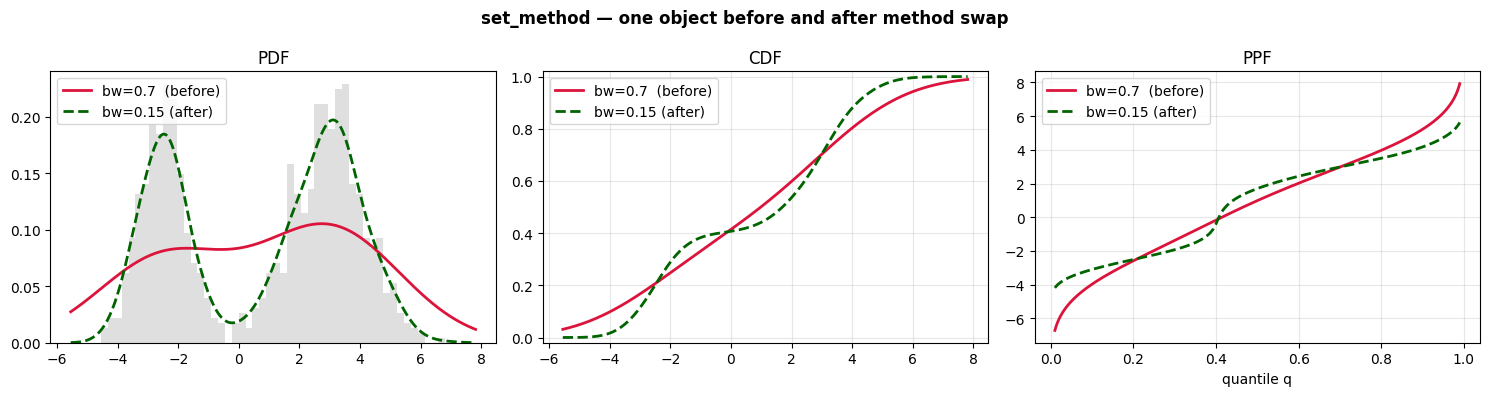

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("set_method — one object before and after method swap", fontweight="bold")

kw_a = {"color": "crimson", "lw": 2, "label": "bw=0.7  (before)"}
kw_b = {"color": "darkgreen", "lw": 2, "ls": "--", "label": "bw=0.15 (after)"}

axes[0].hist(sample, bins=50, density=True, alpha=0.25, color="gray")
axes[0].plot(x, pdf_before, **kw_a)
axes[0].plot(x, pdf_after, **kw_b)
axes[0].set_title("PDF")
axes[0].legend()

axes[1].plot(x, cdf_before, **kw_a)
axes[1].plot(x, cdf_after, **kw_b)
axes[1].set_title("CDF")
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(quant, ppf_before, **kw_a)
axes[2].plot(quant, ppf_after, **kw_b)
axes[2].set_title("PPF")
axes[2].set_xlabel("quantile q")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. `set_method` and the sampler

After `set_method` UNURAN is rebuilt on the next `sample()` call.  
The distribution of new samples matches the updated PDF.

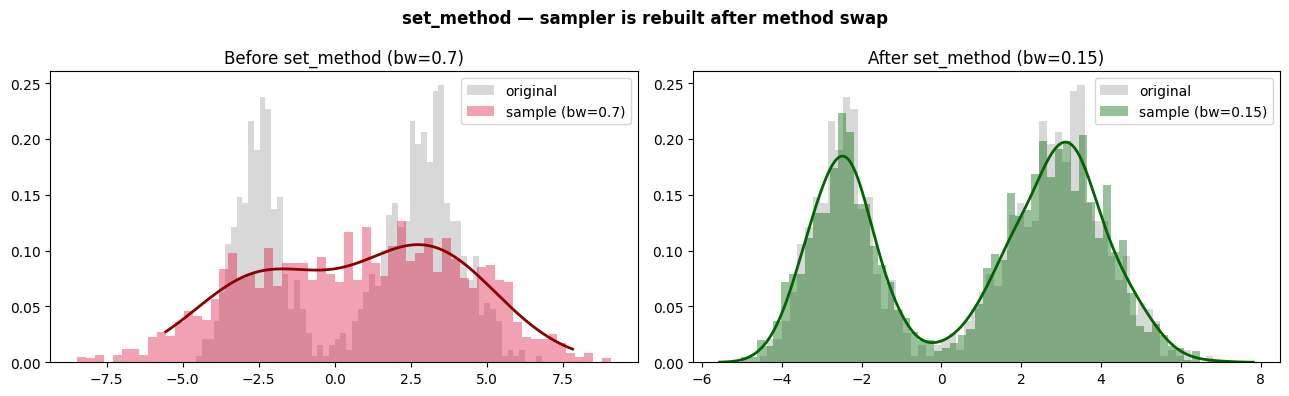

In [9]:
distr_s = EmpiricalDistribution(sample, method=ScipyGaussianKde(bandwidth=0.7))
samples_wide = distr_s.sample(2000)
pdf_wide = distr_s.calculate_characteristic("pdf", x)

distr_s.set_method(ScipyGaussianKde(bandwidth=0.15))
samples_tight = distr_s.sample(2000)
pdf_tight = distr_s.calculate_characteristic("pdf", x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("set_method — sampler is rebuilt after method swap", fontweight="bold")

axes[0].hist(sample, bins=60, density=True, alpha=0.3, color="gray", label="original")
axes[0].hist(
    samples_wide, bins=60, density=True, alpha=0.4, color="crimson", label="sample (bw=0.7)"
)
axes[0].plot(x, pdf_wide, color="darkred", lw=2)
axes[0].set_title("Before set_method (bw=0.7)")
axes[0].legend()

axes[1].hist(sample, bins=60, density=True, alpha=0.3, color="gray", label="original")
axes[1].hist(
    samples_tight, bins=60, density=True, alpha=0.4, color="darkgreen", label="sample (bw=0.15)"
)
axes[1].plot(x, pdf_tight, color="darkgreen", lw=2)
axes[1].set_title("After set_method (bw=0.15)")
axes[1].legend()

plt.tight_layout()
plt.show()